In [1]:
import os
import cv2
import requests
import yaml
import shutil

from tqdm import tqdm
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import cv2

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load a model
model = YOLO('yolov8n-seg.pt')

In [3]:
train_results = model.train(
    data="/home/anmilka/different/dataset/rus_road_signs.yaml",  # path to dataset YAML
    epochs=80,  # number of training epochs
    imgsz=960,  # training image size
    device="5",  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
    workers=8,
    seed=1234,
    batch=64
)

Ultralytics YOLOv8.2.27 🚀 Python-3.10.16 torch-2.2.2+cu121 CUDA:5 (Tesla V100-PCIE-32GB, 32494MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/home/anmilka/different/dataset/rus_road_signs.yaml, epochs=80, time=None, patience=100, batch=64, imgsz=960, save=True, save_period=-1, cache=False, device=5, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=1234, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fal

train: Scanning /home/anmilka/different/dataset/train.cache... 2054 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2054/2054 [00:00<?, ?it/s]
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.5 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning /home/anmilka/different/dataset/val.cache... 127 images, 0 backgrounds, 0 corrupt: 100%|██████████| 127/127 [00:00<?, ?it/s]


Plotting labels to runs/segment/train2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 66 weight(decay=0.0), 77 weight(decay=0.0005), 76 bias(decay=0.0)
Image sizes 960 train, 960 val
Using 8 dataloader workers
Logging results to runs/segment/train2
Starting training for 80 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

      80/80      23.8G     0.7398      0.937       0.41      0.851          9        960: 100%|██████████| 33/33 [00:28<00:00,  1.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.56s/it]

                   all        127        400      0.942      0.823       0.91      0.707      0.934      0.815      0.901      0.595



80 epochs completed in 0.734 hours.
Optimizer stripped from runs/segment/train2/weights/last.pt, 6.9MB
Optimizer stripped from runs/segment/train2/weights/best.pt, 6.9MB

Validating runs/segment/train2/weights/best.pt...
Ultralytics YOLOv8.2.27 🚀 Python-3.10.16 torch-2.2.2+cu121 CUDA:5 (Tesla V100-PCIE-32GB, 32494MiB)
YOLOv8n-seg summary (fused): 195 layers, 3258259 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]


                   all        127        400      0.942      0.823       0.91      0.708      0.936      0.808      0.901      0.597
Speed: 0.3ms preprocess, 1.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/segment/train2



0: 960x960 3 road signs, 51.6ms
1: 960x960 2 road signs, 51.6ms
2: 960x960 2 road signs, 51.6ms
3: 960x960 10 road signs, 51.6ms
Speed: 10.8ms preprocess, 51.6ms inference, 5.1ms postprocess per image at shape (1, 3, 960, 960)


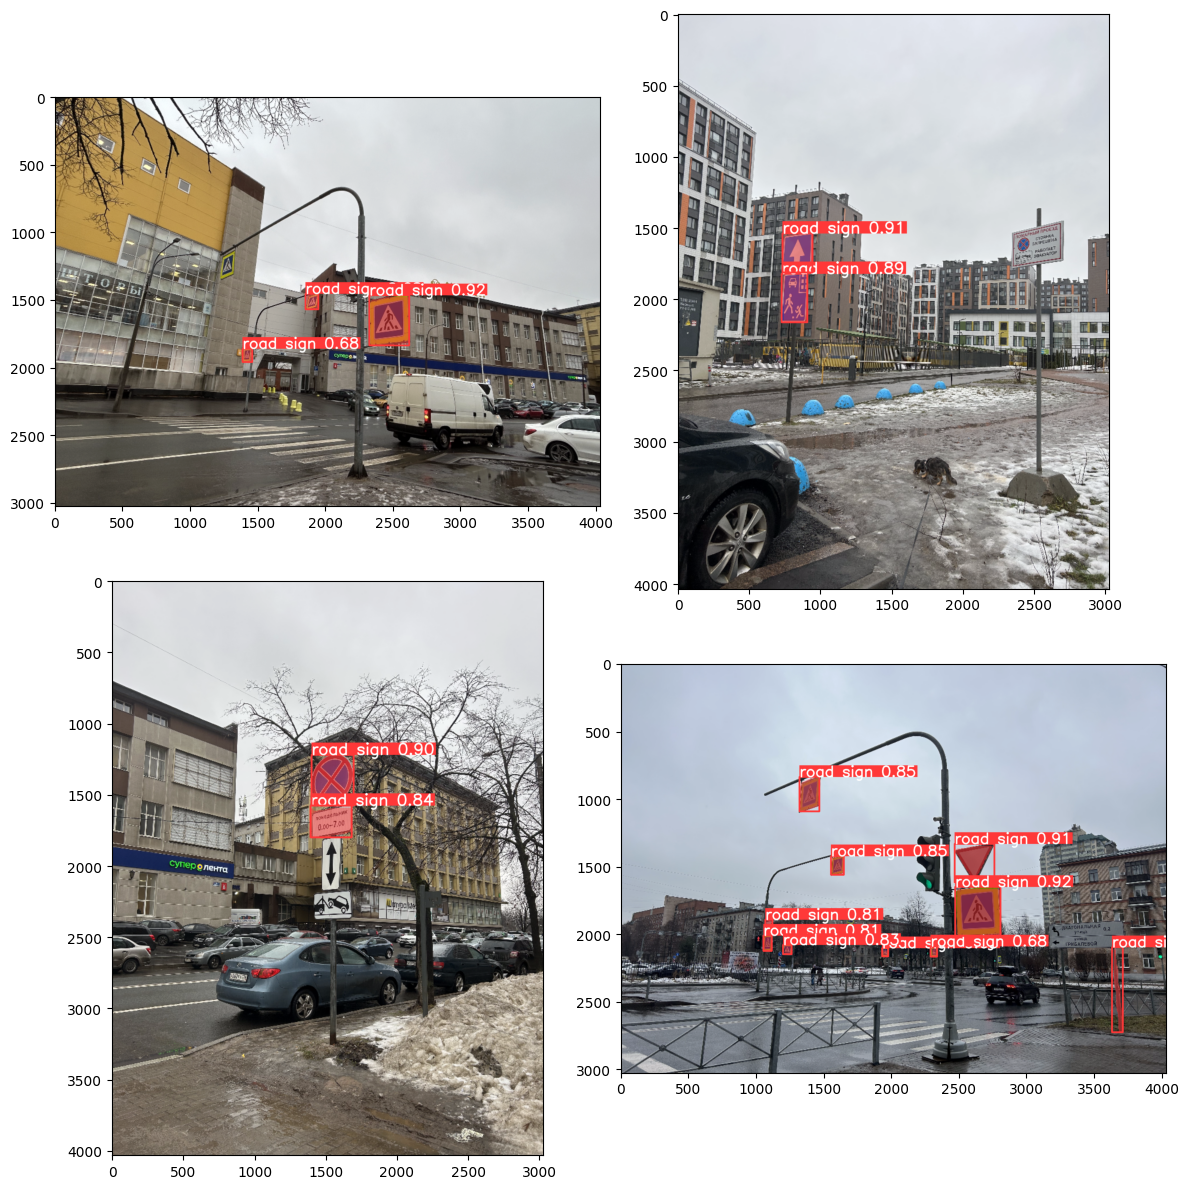

In [ ]:
images = [
    "/home/anmilka/different/street_photo/5.png",
    "/home/anmilka/different/street_photo/7.png",
    "/home/anmilka/different/street_photo/8.png",
    "/home/anmilka/different/street_photo/10.png",
    ]

# Run batched inference on a list of images
results = model(images, conf=0.25)  # return a list of Results objects

# Process results list
rows = 2
cols = 2
figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 12))
for i, res in enumerate(results):
    ax.ravel()[i].imshow(res.plot()[..., ::-1])
plt.tight_layout()
plt.show()

In [6]:
import cv2
import torch
from boxmot import OcSort
from ultralytics import YOLO
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def process_video_OcSort(video_path, output_path):
    cap = cv2.VideoCapture(video_path)
    tracker = OcSort(
        det_thresh=0.2,
        max_age=10,
        min_hits=3,
        asso_threshold=0.15,
        delta_t=1,
        asso_func="diou",
        inertia=0.2,
    )

    if not cap.isOpened():
        print("Ошибка открытия видео файла")
        return

    # Получение параметров видео
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # Создание видеозаписи
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Получение детекций
        results = model(
            frame,
            conf=0.3,
            classes=[0],
            imgsz=960,
        )
        detections = []

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())

                detections.append([x1, y1, x2, y2, conf, cls])

        detections = torch.tensor(detections)
        tracks = tracker.update(detections.cpu().numpy(), np.empty((0,0)))

        # Отображаем треки
        for track in tracks:
            x1, y1, x2, y2, track_id = map(int, track[:5])
            conf = track[5]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{track_id} {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        out.write(frame)

    cap.release()
    out.release()

process_video_OcSort("/home/anmilka/different/street_photo/6.mp4", "/home/anmilka/different/street_photo/6_OcSort.mp4")
process_video_OcSort("/home/anmilka/different/street_photo/9.mp4", "/home/anmilka/different/street_photo/9_OcSort.mp4")


0: 960x544 2 road signs, 1019.5ms
Speed: 10.5ms preprocess, 1019.5ms inference, 9.8ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 27.8ms
Speed: 7.1ms preprocess, 27.8ms inference, 8.1ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 40.9ms
Speed: 5.2ms preprocess, 40.9ms inference, 10.7ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 52.2ms
Speed: 7.3ms preprocess, 52.2ms inference, 33.5ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 27.8ms
Speed: 5.2ms preprocess, 27.8ms inference, 9.8ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 41.1ms
Speed: 10.2ms preprocess, 41.1ms inference, 7.4ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 52.6ms
Speed: 10.3ms preprocess, 52.6ms inference, 21.3ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 38.6ms
Speed: 7.0ms preprocess, 38.6ms inference, 19.7

In [17]:
import torch
import torchvision
import cv2
import numpy as np
from pathlib import Path
from boxmot import BotSort

device = "cuda:0" if torch.cuda.is_available() else "cpu"
# model.to(device)

def process_video_BotSort(video_path, output_path):
    tracker = BotSort(
        reid_weights=Path('osnet_x0_25_msmt17.pt'),  # ReID model to use
        device=device,
        half=False,
    )

    # Open the video file
    vid = cv2.VideoCapture(video_path)

    # Function to generate a unique color for each track ID
    def get_color(track_id):
        np.random.seed(int(track_id))
        return tuple(np.random.randint(0, 255, 3).tolist())

    # Получение параметров видео
    frame_width = int(vid.get(3))
    frame_height = int(vid.get(4))
    fps = int(vid.get(cv2.CAP_PROP_FPS))

    # Создание видеозаписи
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, im = vid.read()
        if not ret:
            break

        # Convert frame to tensor and move to device
        # frame_tensor = torchvision.transforms.functional.to_tensor(im).unsqueeze(0).to(device)

        # Run the Mask R-CNN model to detect bounding boxes and masks
        with torch.no_grad():
            results = model(
                        im,
                        conf=0.3,
                        classes=[0],
                        imgsz=960,
                    )
        
        detections = []

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())

                detections.append([x1, y1, x2, y2, conf, cls])

        # Convert detections to a numpy array (N x (x, y, x, y, conf, cls))
        dets = np.array(detections)

        # Update tracker with detections and image
        tracks = tracker.update(dets, im)  # M x (x, y, x, y, id, conf, cls, ind)

        # Draw segmentation masks and bounding boxes in a single loop
        if len(tracks) > 0:
            inds = tracks[:, 7].astype('int')  # Get track indices as int
            # Iterate over tracks and corresponding masks to draw them together
            for track in tracks:
                track_id = int(track[4])  # Extract track ID
                color = get_color(track_id)  # Use unique color for each track

                # Draw the bounding box
                x1, y1, x2, y2 = track[:4].astype('int')
                cv2.rectangle(im, (x1, y1), (x2, y2), color, 2)
                
                # Add text with ID, confidence, and class
                conf = track[5]
                cls = track[6]
                cv2.putText(im, f'ID: {track_id}, Conf: {conf:.2f}, Class: {cls}', 
                            (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        out.write(im)

    vid.release()
    out.release()

process_video_BotSort("/home/anmilka/different/street_photo/6.mp4", "/home/anmilka/different/street_photo/6_BotSort.mp4")
process_video_BotSort("/home/anmilka/different/street_photo/9.mp4", "/home/anmilka/different/street_photo/9_BotSort.mp4")

2025-03-05 16:29:54.185 | INFO     | boxmot.utils.torch_utils:select_device:52 - Yolo Tracking v11.0.8 🚀 Python-3.10.16 torch-2.2.2+cu121
CUDA:0 (Tesla V100-PCIE-32GB, 32494MiB)
2025-03-05 16:29:54.289 | SUCCESS  | boxmot.appearance.reid_model_factory:load_pretrained_weights:183 - Loaded pretrained weights from osnet_x0_25_msmt17.pt



0: 960x544 2 road signs, 21.0ms
Speed: 4.8ms preprocess, 21.0ms inference, 5.4ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 23.6ms
Speed: 4.3ms preprocess, 23.6ms inference, 5.8ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 20.8ms
Speed: 4.5ms preprocess, 20.8ms inference, 5.8ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 21.8ms
Speed: 4.3ms preprocess, 21.8ms inference, 5.3ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 3 road signs, 20.8ms
Speed: 4.5ms preprocess, 20.8ms inference, 5.5ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 21.6ms
Speed: 4.3ms preprocess, 21.6ms inference, 6.1ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 22.0ms
Speed: 4.7ms preprocess, 22.0ms inference, 5.6ms postprocess per image at shape (1, 3, 960, 544)

0: 960x544 2 road signs, 21.6ms
Speed: 4.1ms preprocess, 21.6ms inference, 5.6ms postproc

2025-03-05 16:30:44.178 | INFO     | boxmot.utils.torch_utils:select_device:52 - Yolo Tracking v11.0.8 🚀 Python-3.10.16 torch-2.2.2+cu121
CUDA:0 (Tesla V100-PCIE-32GB, 32494MiB)
2025-03-05 16:30:44.295 | SUCCESS  | boxmot.appearance.reid_model_factory:load_pretrained_weights:183 - Loaded pretrained weights from osnet_x0_25_msmt17.pt



0: 544x960 14 road signs, 25.9ms
Speed: 4.6ms preprocess, 25.9ms inference, 7.0ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 14 road signs, 23.4ms
Speed: 4.5ms preprocess, 23.4ms inference, 6.6ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 14 road signs, 23.7ms
Speed: 4.4ms preprocess, 23.7ms inference, 7.1ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 13 road signs, 28.0ms
Speed: 5.4ms preprocess, 28.0ms inference, 7.5ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 13 road signs, 22.0ms
Speed: 4.2ms preprocess, 22.0ms inference, 6.0ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 14 road signs, 27.1ms
Speed: 5.1ms preprocess, 27.1ms inference, 7.3ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 13 road signs, 22.8ms
Speed: 4.3ms preprocess, 22.8ms inference, 6.4ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 14 road signs, 27.7ms
Speed: 5.5ms preprocess, 27.7ms inference, 7.5ms 